In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [211]:
synthetic_dataset_paths = {
    "TabDDPM": 'https://raw.githubusercontent.com/imets01/synthetic_network_data_gen/refs/heads/main/high_level_features/tabddpm/synthetic_data.csv',
    "CTGAN": 'https://raw.githubusercontent.com/imets01/synthetic_network_data_gen/refs/heads/main/high_level_features/CTGAN/synthetic_data_high_level_ctgan.csv'
}
real_dataset_path = 'https://raw.githubusercontent.com/imets01/synthetic_network_data_gen/refs/heads/main/high_level_features/dataset/all_captures_dataset.csv'

ideal_high_level_features = [
    'handshake_duration', 'time_to_migration', 'migration_duration', 
    'packets_before_migration', 'total_bidi_streams_client_init', 
    'total_udi_streams_client_init', 'bytes_sent_client', 
    'bytes_sent_server', 'retry_occurred', 'path_validation_initiated',
    'version_negotiation_occurred', 'connection_close_type'
]

categorical_features = [
    'retry_occurred', 'path_validation_initiated', 
    'version_negotiation_occurred', 'connection_close_type'
]

real_dataset = pd.read_csv(real_dataset_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [212]:
def prepare_data_for_feature_inspection(raw_training_data, raw_test_data, dataset_name):
    training_data = raw_training_data.copy()
    test_data = raw_test_data.copy()

    # Standardizing Data
    if "Target" in training_data.columns:
        training_data = training_data.rename(columns={"Target": "implementation"})
    
    cols_to_fix = ['version_negotiation_occurred', 'retry_occurred', 'path_validation_initiated']
    for col in cols_to_fix:
        if col in training_data.columns:
            training_data[col] = training_data[col].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)
    
    # Cleaning Missing Values and Resetting Index
    training_data = training_data.dropna().reset_index(drop=True)
    test_data = test_data.dropna().reset_index(drop=True)

    # Feature Inspection
    current_features = [f for f in ideal_high_level_features if f in training_data.columns]
    print(f"{dataset_name}")
    print(f"Number of features: {len(current_features)}")
    print(f"Current features: {current_features}")
    print(f"Missing features: {list(set(ideal_high_level_features) - set(current_features))}")
    print("="*60)
    
    return training_data, test_data, current_features

# TabDDPM
tabddpm_raw_data = pd.read_csv(synthetic_dataset_paths["TabDDPM"])
tabddpm_clean_data, tabddpm_real_data, tabddpm_features= prepare_data_for_feature_inspection(tabddpm_raw_data, real_dataset, "TabDDPM")

# CTGAN
ctgan_raw_data = pd.read_csv(synthetic_dataset_paths["CTGAN"])
ctgan_clean_data, ctgan_real_data, ctgan_features = prepare_data_for_feature_inspection(ctgan_raw_data, real_dataset, "CTGAN")

TabDDPM
Number of features: 12
Current features: ['handshake_duration', 'time_to_migration', 'migration_duration', 'packets_before_migration', 'total_bidi_streams_client_init', 'total_udi_streams_client_init', 'bytes_sent_client', 'bytes_sent_server', 'retry_occurred', 'path_validation_initiated', 'version_negotiation_occurred', 'connection_close_type']
Missing features: []
CTGAN
Number of features: 9
Current features: ['handshake_duration', 'time_to_migration', 'migration_duration', 'packets_before_migration', 'total_bidi_streams_client_init', 'total_udi_streams_client_init', 'retry_occurred', 'path_validation_initiated', 'version_negotiation_occurred']
Missing features: ['connection_close_type', 'bytes_sent_client', 'bytes_sent_server']


In [213]:
def train_random_forest_and_evaluate_utility(training_data, test_data, current_features):
    
    # Encoding Categorical Columns
    current_categorical_columns = [c for c in categorical_features if c in current_features]
    for col in current_categorical_columns:
        le = LabelEncoder()
        le.fit(pd.concat([training_data[col].astype(str), test_data[col].astype(str)]))
        training_data[col] = le.transform(training_data[col].astype(str))
        test_data[col] = le.transform(test_data[col].astype(str))

    # Labeling Target Variable
    y_train_raw = training_data["implementation"]
    if len(y_train_raw.shape) > 1: y_train_raw = y_train_raw.iloc[:, 0]
    
    y_test_raw = test_data["implementation"]
    if len(y_test_raw.shape) > 1: y_test_raw = y_test_raw.iloc[:, 0]

    le_target_data = LabelEncoder()
    y_train = le_target_data.fit_transform(y_train_raw.astype(str))
    y_test = le_target_data.transform(y_test_raw.astype(str))
    
    # Model Training
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(training_data[current_features], y_train)
    preds = model.predict(test_data[current_features])
    
    return y_test, preds, le_target_data, model


y_test_tabddpm, preds_tabddpm, le_tabddpm, model_tabddpm = train_random_forest_and_evaluate_utility(tabddpm_clean_data, tabddpm_real_data, tabddpm_features)
y_test_ctgan, preds_ctgan, le_ctgan, model_ctgan = train_random_forest_and_evaluate_utility(ctgan_clean_data, ctgan_real_data, ctgan_features)

                          TabDDPM                           

Accuracy: 1.0000

Classification Results:

              precision    recall  f1-score   support

     aioquic       1.00      1.00      1.00      2750
       nginx       1.00      1.00      1.00      2982
      quicgo       1.00      1.00      1.00      2995
      quiche       1.00      1.00      1.00      3170

    accuracy                           1.00     11897
   macro avg       1.00      1.00      1.00     11897
weighted avg       1.00      1.00      1.00     11897



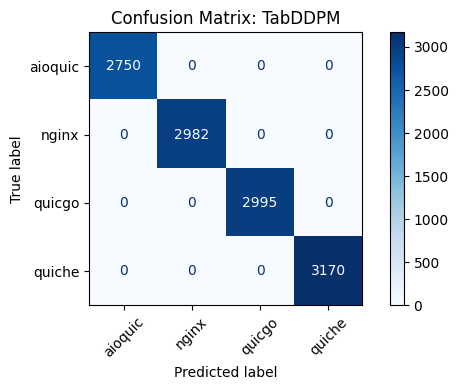

                           CTGAN                            

Accuracy: 0.9258

Classification Results:

              precision    recall  f1-score   support

     aioquic       0.86      0.96      0.91      2750
       nginx       0.88      0.98      0.93      2982
      quicgo       0.99      0.89      0.94      2995
      quiche       0.98      0.87      0.92      3170

    accuracy                           0.93     11897
   macro avg       0.93      0.93      0.93     11897
weighted avg       0.93      0.93      0.93     11897



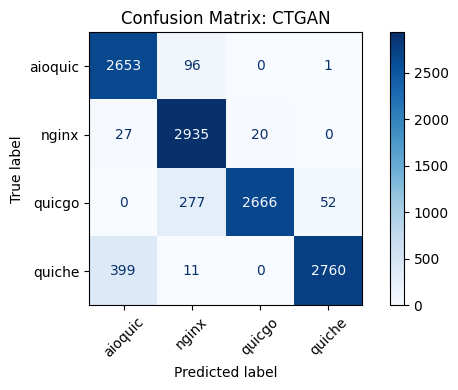

In [220]:
def show_results_and_confusion_matrix(y_true, y_predicted, le, dataset_name):
    
    # Evaluation Results
    print(f"{dataset_name.center(60)}\n")
    print(f"Accuracy: {accuracy_score(y_true, y_predicted):.4f}")
    print("\nClassification Results:\n")
    print(classification_report(y_true, y_predicted, target_names=le.classes_, zero_division=0))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 4))
    cm = confusion_matrix(y_true, y_predicted)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", ax=ax, values_format='d', xticks_rotation=45)
    plt.title(f"Confusion Matrix: {dataset_name}")
    plt.tight_layout()
    plt.show()


show_results_and_confusion_matrix(y_test_tabddpm, preds_tabddpm, le_tabddpm, "TabDDPM")
show_results_and_confusion_matrix(y_test_ctgan, preds_ctgan, le_ctgan, "CTGAN")

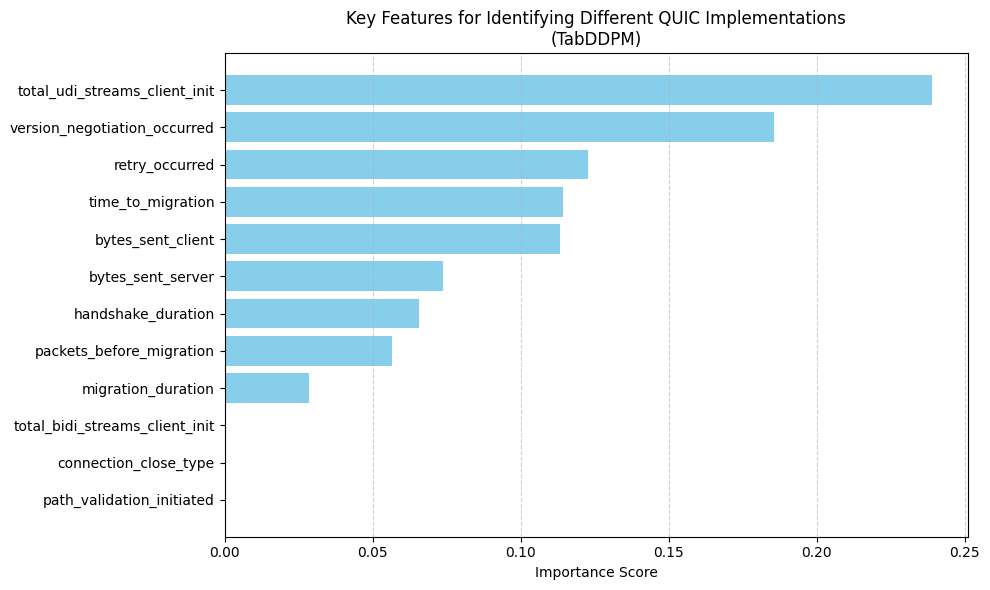

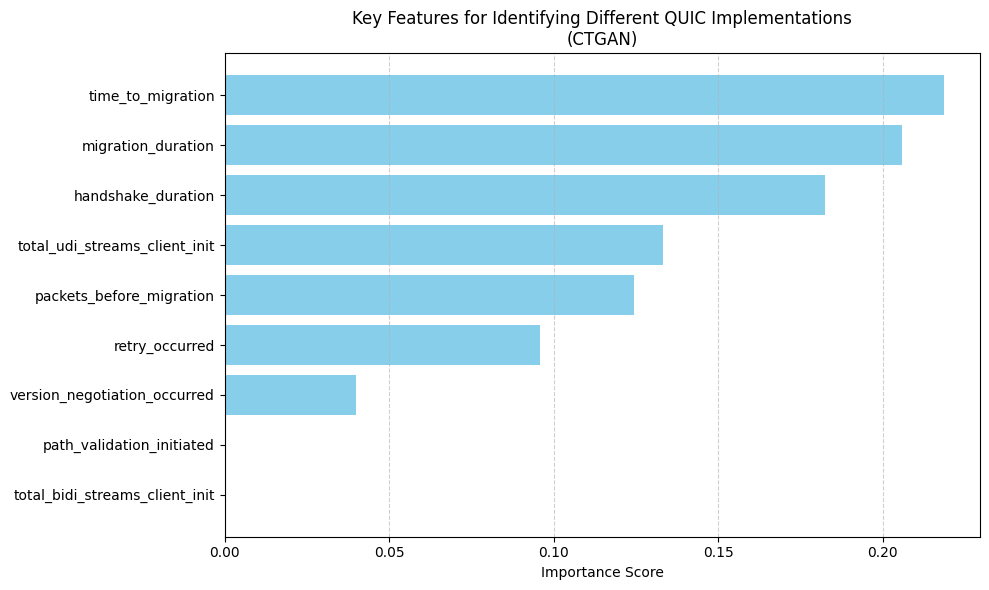

In [218]:
def plot_feature_importance(model, features, dataset_name):
    
    importance = model.feature_importances_
    indices = np.argsort(importance)

    plt.figure(figsize=(10, 6))
    plt.title(f"Key Features for Identifying Different QUIC Implementations\n({dataset_name})")
    plt.barh(range(len(indices)), importance[indices], color='skyblue', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Importance Score')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Plots
plot_feature_importance(model_tabddpm, tabddpm_features, "TabDDPM")
plot_feature_importance(model_ctgan, ctgan_features, "CTGAN")